# Indonesian Sentiment Analysis
## NLP Technical Test — nolimit.id

**Task:** Text Classification — Sentiment Analysis (Positive / Neutral / Negative)  
**Dataset:** [NusaX-senti](https://huggingface.co/datasets/indonlp/NusaX-senti)  
**Model:** `indobenchmark/indobert-base-p1` (IndoBERT via HuggingFace)  
**Embeddings:** `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` + FAISS


## 1️. Install Dependencies

In [1]:
!pip install -q transformers datasets sentence-transformers faiss-cpu scikit-learn pandas matplotlib seaborn torch accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 47.5 MB/s eta 0:00:00


## 2️. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import faiss

# Device setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device: {device}')
print(f'✅ PyTorch version: {torch.__version__}')

✅ Device: cpu
✅ PyTorch version: 2.11.0+cpu


## 3️. Load Dataset — NusaX-senti (Indonesian)

> **Source:** https://huggingface.co/datasets/indonlp/NusaX-senti  
> **License:** CC-BY-SA 4.0  
> **Subset:** `ind` (Bahasa Indonesia)  
> **Labels:** `negative` (0), `neutral` (1), `positive` (2)  
> **Size:** 1000 texts — train/500 · val/100 · test/400  
> **Load method:** Direct Parquet via HuggingFace Datasets-Server API (no loading script)


In [16]:
# Strategy: load Parquet files directly via HuggingFace Datasets-Server API

import requests

def get_parquet_urls(dataset_id, config, split):
    """Fetch Parquet URLs from HuggingFace datasets-server."""
    url = f'https://datasets-server.huggingface.co/parquet?dataset={dataset_id}'
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    parquet_files = resp.json()['parquet_files']
    return [
        f['url'] for f in parquet_files
        if f['config'] == config and f['split'] == split
    ]

# Get Parquet URLs for each split (Indonesian subset)
DATASET_ID = 'indonlp/NusaX-senti'
CONFIG     = 'ind'   # Bahasa Indonesia

train_urls = get_parquet_urls(DATASET_ID, CONFIG, 'train')
val_urls   = get_parquet_urls(DATASET_ID, CONFIG, 'validation')
test_urls  = get_parquet_urls(DATASET_ID, CONFIG, 'test')

print('Train URLs:', train_urls)
print('Val URLs  :', val_urls)
print('Test URLs :', test_urls)

# Load directly as DatasetDict using load_dataset('parquet', data_files=...)
from datasets import load_dataset, DatasetDict

dataset = DatasetDict({
    'train':      load_dataset('parquet', data_files=train_urls, split='train'),
    'validation': load_dataset('parquet', data_files=val_urls,   split='train'),
    'test':       load_dataset('parquet', data_files=test_urls,  split='train'),
})

print('\nDataset:', dataset)

df_train = pd.DataFrame(dataset['train'])
df_val   = pd.DataFrame(dataset['validation'])
df_test  = pd.DataFrame(dataset['test'])

print(f'\n📊 Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
df_train.head(10)

Train URLs: ['https://huggingface.co/datasets/indonlp/NusaX-senti/resolve/refs%2Fconvert%2Fparquet/ind/train/0000.parquet']
Val URLs  : ['https://huggingface.co/datasets/indonlp/NusaX-senti/resolve/refs%2Fconvert%2Fparquet/ind/validation/0000.parquet']
Test URLs : ['https://huggingface.co/datasets/indonlp/NusaX-senti/resolve/refs%2Fconvert%2Fparquet/ind/test/0000.parquet']

Dataset: DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'lang', 'label'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['id', 'text', 'lang', 'label'],
        num_rows: 100
    })
    test: Dataset({
        features: ['id', 'text', 'lang', 'label'],
        num_rows: 400
    })
})

📊 Train: 500 | Val: 100 | Test: 400


,id,text,lang,label
0,219,Nikmati cicilan 0% hingga 12 bulan untuk pemes...,ind,1
1,209,Kue-kue yang disajikan bikin saya bernostalgia...,ind,2
2,436,Ibu pernah bekerja di grab indonesia,ind,1
3,394,Paling suka banget makan siang di sini ayam sa...,ind,2
4,592,Pelayanan bus DAMRI sangat baik,ind,2
5,317,Mau bikin postingan yang isinya mengedukasi cu...,ind,1
6,352,Ratusan rumah di medan terendam banjir,ind,1
7,751,"Barangnya lumayan, cuma yang saya heran xiaomi...",ind,0
8,856,Sulit sekali mempercayai orang yang sudah pern...,ind,0
9,504,"Lokasi di gombel dengan pemandangan semarang, ...",ind,2


In [31]:
# Derive labels from ACTUAL data (not features metadata)

unique_labels = sorted(df_train['label'].unique().tolist())
print('Unique label values in train data:', unique_labels)
print('Label dtype:', df_train['label'].dtype)

# Map integer labels to sentiment names
label_names = ['negative', 'neutral', 'positive']
num_labels  = len(label_names)

id2label = {i: l for i, l in enumerate(label_names)}
label2id = {l: i for i, l in enumerate(label_names)}

print(f'num_labels : {num_labels}')
print(f'id2label   : {id2label}')

# Sanity check — label values in data must be within [0, num_labels)
assert all(v in id2label for v in unique_labels), \
    f'Unexpected label values: {unique_labels}. Expected: {list(id2label.keys())}'
print('✅ Label mapping validated')


Unique label values in train data: [0, 1, 2]
Label dtype: int64
num_labels : 3
id2label   : {0: 'negative', 1: 'neutral', 2: 'positive'}
✅ Label mapping validated


## 4️. Exploratory Data Analysis (EDA)

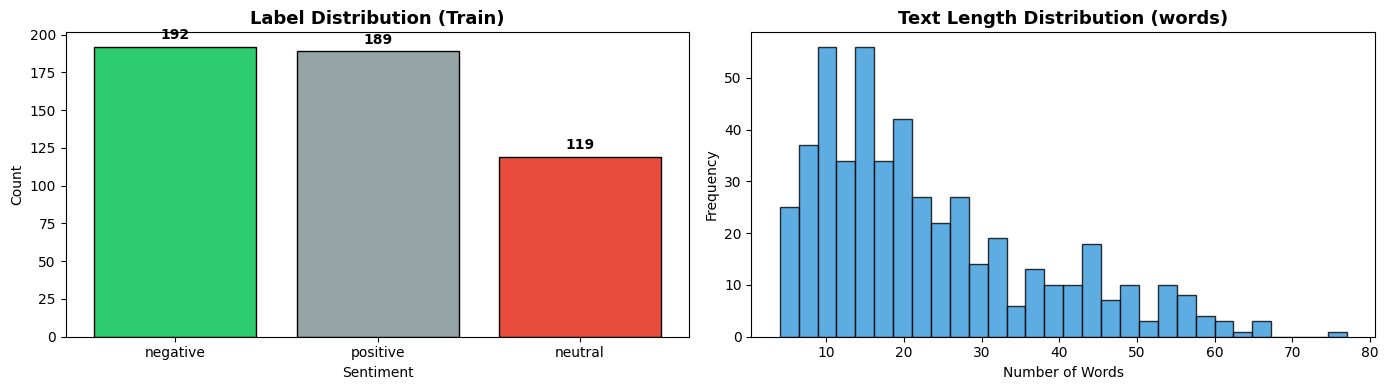


Avg text length: 23.1 words
Max text length: 77 words


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Label distribution
label_counts = df_train['label'].map(id2label).value_counts()
axes[0].bar(label_counts.index, label_counts.values,
            color=['#2ecc71', '#95a5a6', '#e74c3c'], edgecolor='black')
axes[0].set_title('Label Distribution (Train)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Text length distribution
df_train['text_len'] = df_train['text'].apply(lambda x: len(x.split()))
axes[1].hist(df_train['text_len'], bins=30, color='#3498db', edgecolor='black', alpha=0.8)
axes[1].set_title('Text Length Distribution (words)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAvg text length: {df_train["text_len"].mean():.1f} words')
print(f'Max text length: {df_train["text_len"].max()} words')

## 5️. Tokenization — IndoBERT

In [33]:
MODEL_NAME = 'indobenchmark/indobert-base-p1'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

# Tokenize all splits
tokenized = dataset.map(tokenize_fn, batched=True)
tokenized = tokenized.rename_column('label', 'labels')

tokenized = tokenized.remove_columns(
    [col for col in tokenized['train'].column_names
     if col not in ('input_ids', 'attention_mask', 'token_type_ids', 'labels')]
)

print('✅ Tokenization complete')
print('Columns:', tokenized['train'].column_names)
print('Sample input_ids (first 10):', tokenized['train'][0]['input_ids'][:10])


✅ Tokenization complete
Columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Sample input_ids (first 10): [2, 8822, 12914, 502, 30461, 733, 981, 823, 90, 3927]


## 6️. Fine-Tune IndoBERT for Sentiment Classification

In [34]:
# Load pre-trained model with classification head
# num_labels derived from label_names (verified above) — never hardcoded
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,   # 3: positive / neutral / negative
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True  # suppress size-mismatch warning from pre-trained head
)
model.to(device)

print(f'✅ Model loaded : {MODEL_NAME}')
print(f'   num_labels  : {num_labels}')
print(f'   Parameters  : {sum(p.numel() for p in model.parameters()):,}')


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded : indobenchmark/indobert-base-p1
   num_labels  : 3
   Parameters  : 124,443,651


In [35]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1);
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro')
    }

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    report_to='none',
    fp16=(device == 'cuda'),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    # tokenizer=tokenizer, # Removed this argument
    compute_metrics=compute_metrics,
)

print('🚀 Starting fine-tuning...')
trainer.train()
print('✅ Training complete!')

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


🚀 Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.517259,0.860000,0.851595
2,0.730295,0.378758,0.880000,0.879048
3,0.730295,0.648608,0.870000,0.865714


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training complete!


## 7️. Evaluation on Test Set

In [36]:
# Predict on test set
predictions = trainer.predict(tokenized['test'])
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print('=' * 50)
print('📊 Classification Report (Test Set)')
print('=' * 50)
print(classification_report(true_labels, preds, target_names=label_names))

📊 Classification Report (Test Set)
              precision    recall  f1-score   support

    negative       0.94      0.87      0.90       153
     neutral       0.79      0.88      0.83        96
    positive       0.93      0.93      0.93       151

    accuracy                           0.90       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.90      0.90      0.90       400



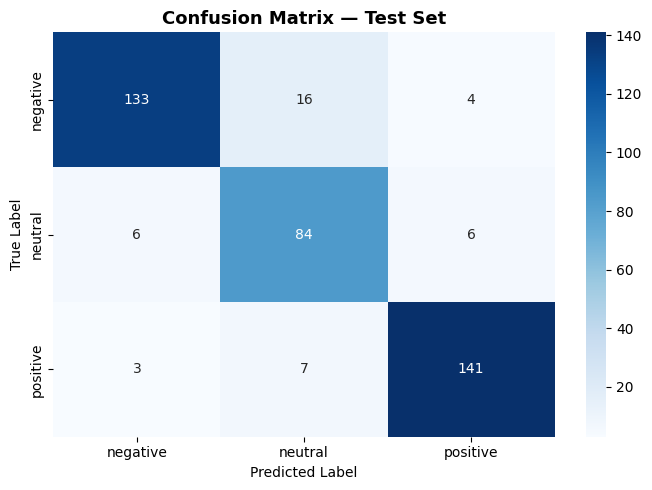

In [37]:
# Confusion Matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8️. Sentence Embeddings + FAISS Index

> Build a semantic search index over the training set using `sentence-transformers`

In [38]:
EMBED_MODEL = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
embedder = SentenceTransformer(EMBED_MODEL, device=device)

print(f'✅ Embedding model loaded: {EMBED_MODEL}')

# Use a subset for speed (full dataset can take a while on CPU)
sample_texts = df_train['text'].tolist()[:1000]
sample_labels = [id2label[int(l)] for l in df_train['label'].tolist()[:500]]

print(f'🔄 Encoding {len(sample_texts)} texts...')
embeddings = embedder.encode(sample_texts, batch_size=64,
                              show_progress_bar=True, normalize_embeddings=True)

print(f'✅ Embeddings shape: {embeddings.shape}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Embedding model loaded: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
🔄 Encoding 500 texts...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

✅ Embeddings shape: (500, 384)


In [39]:
# Build FAISS index (cosine similarity via inner product on normalized vectors)
dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)   # Inner Product = cosine on normalized vecs
index.add(embeddings.astype('float32'))

print(f'✅ FAISS index built: {index.ntotal} vectors | dim={dim}')

# Save index
faiss.write_index(index, 'smsa_faiss.index')
print('💾 Index saved: smsa_faiss.index')

✅ FAISS index built: 500 vectors | dim=384
💾 Index saved: smsa_faiss.index


## 9️. Inference Pipeline — Sentiment Prediction + Semantic Search

In [40]:
# Inference helper
clf_pipeline = pipeline(
    'text-classification',
    model=model,
    tokenizer=tokenizer,
    device=0 if device == 'cuda' else -1
)

def predict_sentiment(text, top_k_similar=3):
    """Predict sentiment and retrieve semantically similar examples."""
    # 1. Sentiment prediction
    result   = clf_pipeline(text, truncation=True, max_length=128)[0]
    sentiment = result['label']
    score     = result['score']

    # 2. Embed query + FAISS search
    q_embed = embedder.encode([text], normalize_embeddings=True).astype('float32')
    D, I    = index.search(q_embed, top_k_similar + 1)  # +1 in case exact match

    similar = []
    for dist, idx in zip(D[0], I[0]):
        if idx < len(sample_texts):
            similar.append({
                'text':      sample_texts[idx],
                'label':     id2label[sample_labels[idx]],
                'similarity': float(dist)
            })

    return {
        'input':    text,
        'sentiment': sentiment,
        'confidence': round(score * 100, 2),
        'similar_examples': similar[:top_k_similar]
    }

print('✅ Inference pipeline ready')

✅ Inference pipeline ready


In [42]:
# Example Outputs

def predict_sentiment(text, top_k_similar=3):
    """Predict sentiment and retrieve semantically similar examples."""
    # 1. Sentiment prediction
    result   = clf_pipeline(text, truncation=True, max_length=128)[0]
    sentiment = result['label']
    score     = result['score']

    # 2. Embed query + FAISS search
    q_embed = embedder.encode([text], normalize_embeddings=True).astype('float32')
    D, I    = index.search(q_embed, top_k_similar + 1)  # +1 in case exact match

    similar = []
    for dist, idx in zip(D[0], I[0]):
        if idx < len(sample_texts):
            similar.append({
                'text':      sample_texts[idx],
                'label':     sample_labels[idx],
                'similarity': float(dist)
            })

    return {
        'input':    text,
        'sentiment': sentiment,
        'confidence': round(score * 100, 2),
        'similar_examples': similar[:top_k_similar]
    }

print('=' * 65)
print('  CONTOH OUTPUT — SENTIMENT ANALYSIS')
print('=' * 65)

for i, text in enumerate(test_samples, 1):
    res = predict_sentiment(text)
    emoji = {'positive': '✅', 'neutral': '⚪', 'negative': '❌'}.get(res['sentiment'], '❓')
    print(f'\n[{i}] Input   : "{res["input"]}"')
    print(f'    Sentimen : {emoji} {res["sentiment"].upper()} ({res["confidence"]}%)')
    print(f'    Contoh Serupa (FAISS):')
    for ex in res['similar_examples']:
        em2 = {'positive': '✅', 'neutral': '⚪', 'negative': '❌'}.get(ex['label'], '❓')
        print(f'      {em2} [{ex["label"]:<8}] sim={ex["similarity"]:.3f} — "{ex["text"][:55]}..."')

print('\n' + '=' * 65)

  CONTOH OUTPUT — SENTIMENT ANALYSIS

[1] Input   : "Produk ini sangat bagus dan pengiriman cepat, puas banget!"
    Sentimen : ✅ POSITIVE (99.11%)
    Contoh Serupa (FAISS):
      ✅ [positive] sim=0.668 — "Enkaolshop, terpercaya, barangnya bagus bagus..."
      ✅ [positive] sim=0.635 — "Penyajian cukup cepat, pelayanan baik dan pastinya masa..."
      ✅ [positive] sim=0.584 — "Steiknya lumayanlah enak. Warung ini cocok buat pelajar..."

[2] Input   : "Biasa saja, tidak ada yang istimewa dari produk ini."
    Sentimen : ⚪ NEUTRAL (49.87%)
    Contoh Serupa (FAISS):
      ❌ [negative] sim=0.526 — "Walaupun porsinya besar, tapi secara rasa, biasa saja. ..."
      ⚪ [neutral ] sim=0.515 — "Yang benar-benar real tidak ada settingan..."
      ✅ [positive] sim=0.498 — "Roti bakar duti ini sudah ada sejak dulu di sini. Rotin..."

[3] Input   : "Sangat kecewa, barang datang rusak dan pelayanan buruk."
    Sentimen : ❌ NEGATIVE (97.47%)
    Contoh Serupa (FAISS):
      ❌ [negative] sim=0.613 — 

## Save Model

In [43]:
model.save_pretrained('./indobert-sentiment-nusax')
tokenizer.save_pretrained('./indobert-sentiment-nusax')
print('💾 Model saved to ./indobert-sentiment-nusax')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Model saved to ./indobert-sentiment-nusax


In [47]:
import json

path = "/content/drive/MyDrive/Colab Notebooks/NoLimit - Sentiment Analysis.ipynb"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Memulai pembersihan total...")
diperbaiki = False

if "metadata" in data and "widgets" in data["metadata"]:
    del data["metadata"]["widgets"]
    diperbaiki = True
    print("- Menghapus widgets dari root metadata.")

if "cells" in data:
    for i, cell in enumerate(data["cells"]):
        if "metadata" in cell and "widgets" in cell["metadata"]:
            del cell["metadata"]["widgets"]
            diperbaiki = True
            print(f"- Menghapus widgets dari metadata Cell ke-{i+1}.")

if diperbaiki:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=1)
    print("Selesai! Semua metadata widgets yang rusak telah dibersihkan.")
else:
    print("Tidak ditemukan metadata widgets sama sekali di file ini.")


Memulai pembersihan total...
Tidak ditemukan metadata widgets sama sekali di file ini.
